# Employee Attrition Prediction using Machine Learning

## Task 1: Data Loading & Initial Exploration

### Objective
The objective of this task is to understand the structure of the employee attrition dataset before building any machine learning models. This includes loading the dataset, exploring its dimensions, identifying the target variable, examining feature types, and understanding the distribution of employee attrition.

A thorough exploration helps identify potential preprocessing requirements and provides an overview of the dataset that will guide subsequent analysis.

In [9]:
# Import required libraries

import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

## Step 1: Load the Dataset

The IBM HR Analytics Employee Attrition dataset is loaded using the Pandas library. After loading the dataset, we verify that it has been imported successfully.

In [10]:
# Load the dataset

df = pd.read_csv("HR_Attrition.csv")

# Display the first 10 rows

df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


## Step 2: Dataset Dimensions

Understanding the number of rows and columns provides an overview of the dataset size and helps estimate the computational requirements for analysis.

In [11]:
print("Dataset Shape:", df.shape)

print("\nNumber of Rows:", df.shape[0])

print("Number of Columns:", df.shape[1])

Dataset Shape: (1470, 35)

Number of Rows: 1470
Number of Columns: 35


## Step 3: Identify the Target Variable

The target variable represents whether an employee has left the company or is still working. In this dataset, the target column is **Attrition**, which contains two categories:

- Yes → Employee left the company
- No → Employee stayed in the company

In [12]:
print("Target Column:")

print(df["Attrition"].head())

Target Column:
0    Yes
1     No
2    Yes
3     No
4     No
Name: Attrition, dtype: object


## Step 4: Attrition Distribution

The distribution of employees who stayed versus those who left is calculated to understand the balance of the target variable. The attrition rate is one of the most important business metrics because it reflects employee retention within the organization.

In [13]:
# Count employees who stayed and left

attrition_count = df["Attrition"].value_counts()

print(attrition_count)

# Calculate attrition rate

attrition_rate = (attrition_count["Yes"] / len(df)) * 100

print(f"\nOverall Attrition Rate: {attrition_rate:.2f}%")

Attrition
No     1233
Yes     237
Name: count, dtype: int64

Overall Attrition Rate: 16.12%


## Step 5: Identify Numerical and Categorical Features

Machine learning algorithms require numerical inputs. Therefore, identifying numerical and categorical features is an essential preprocessing step before model building.

In [14]:
# Separate numerical and categorical columns

numerical_cols = df.select_dtypes(include=['int64','float64']).columns

categorical_cols = df.select_dtypes(include=['object']).columns

print("Number of Numerical Columns:", len(numerical_cols))

print("Number of Categorical Columns:", len(categorical_cols))

print("\nNumerical Columns:")

print(list(numerical_cols))

print("\nCategorical Columns:")

print(list(categorical_cols))

Number of Numerical Columns: 26
Number of Categorical Columns: 9

Numerical Columns:
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categorical Columns:
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


## Observation

The dataset contains **26 numerical features** and **9 categorical features**, providing a balanced mix of quantitative and qualitative employee information. The target variable, **Attrition**, is categorical with two classes: **Yes** (employee left) and **No** (employee stayed). Based on the attrition count, only a small proportion of employees have left the company, indicating that the dataset is **imbalanced**, with significantly more employees staying than leaving. This class imbalance should be considered during model training to prevent the models from being biased toward the majority class.

# Task 2: Data Cleaning & Preprocessing

## Objective

Before training machine learning models, the dataset must be cleaned and transformed into a suitable format. This process includes checking for missing values, removing irrelevant columns, encoding categorical variables into numerical form, and scaling numerical features. Proper preprocessing improves model performance and ensures that the algorithms can learn meaningful patterns from the data.

## Step 1: Checking Missing Values

Missing values can negatively impact machine learning models. Therefore, the dataset is first inspected to identify whether any feature contains null values.

In [15]:
# Check missing values

missing_values = df.isnull().sum()

print("Missing Values in Each Column:")
print(missing_values)

print("\nTotal Missing Values:", missing_values.sum())

Missing Values in Each Column:
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCu

## Step 2: Removing Irrelevant Columns

Some columns do not contribute to prediction because they either contain unique identifiers or constant values. Removing these features helps reduce unnecessary complexity and improves model efficiency.

In [16]:
# Columns to remove

columns_to_drop = [
    "EmployeeNumber",
    "EmployeeCount",
    "Over18",
    "StandardHours"
]

df.drop(columns=columns_to_drop, inplace=True)

print("Updated Dataset Shape:", df.shape)

Updated Dataset Shape: (1470, 31)


## Step 3: Encoding the Target Variable

The target variable **Attrition** is converted from categorical values (Yes/No) into numerical values (1/0), making it suitable for machine learning algorithms.

In [17]:
df["Attrition"] = df["Attrition"].map({
    "Yes": 1,
    "No": 0
})

print(df["Attrition"].value_counts())

Attrition
0    1233
1     237
Name: count, dtype: int64


## Step 4: Encoding Categorical Features

Machine learning algorithms require numerical input. Therefore, all remaining categorical variables are converted into numerical features using One-Hot Encoding.

In [18]:
# Separate categorical columns

categorical_columns = df.select_dtypes(include="object").columns

print("Categorical Columns:")
print(list(categorical_columns))

# One-Hot Encoding

df = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True
)

print("\nDataset Shape After Encoding:", df.shape)

Categorical Columns:
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Dataset Shape After Encoding: (1470, 45)


## Step 5: Feature Scaling

Since numerical features have different ranges, feature scaling is applied using StandardScaler. Scaling ensures that all numerical variables contribute equally during model training.

from sklearn.preprocessing import StandardScaler

# Separate features and target

X = df.drop("Attrition", axis=1)

y = df["Attrition"]

# Scale Features

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Feature Scaling Completed Successfully!")

print("Scaled Feature Matrix Shape:", X_scaled.shape)

## Observation

The dataset was successfully preprocessed for machine learning analysis. No missing values were found, confirming that the dataset was already clean. Irrelevant columns such as **EmployeeNumber**, **EmployeeCount**, **Over18**, and **StandardHours** were removed as they do not contribute to predicting employee attrition. The target variable **Attrition** was converted into binary format (Yes = 1, No = 0), while all remaining categorical features were transformed into numerical features using One-Hot Encoding. Finally, feature scaling was performed using **StandardScaler**, resulting in a processed feature matrix of **1,470 employee records** and **44 input features**. The dataset is now fully prepared for exploratory data analysis and machine learning model development.

# Task 3: Exploratory Data Analysis (EDA)

## Chart 1: Attrition Rate by Department

### Objective

This analysis evaluates the employee attrition rate across different departments to identify which department experiences the highest turnover. Understanding departmental attrition enables HR teams to focus retention efforts on departments where employee exits are more frequent, thereby improving workforce stability and reducing recruitment costs.

Department
Sales                     20.627803
Human Resources           19.047619
Research & Development    13.839750
Name: Attrition, dtype: float64


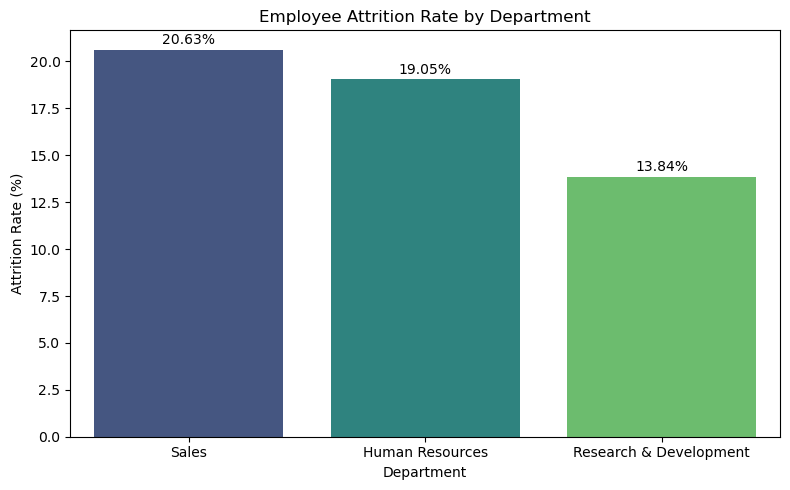

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Fresh copy of dataset for EDA
eda = pd.read_csv("HR_Attrition.csv")

# Calculate attrition rate
department_attrition = (
    eda.groupby("Department")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

print(department_attrition)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=department_attrition.index,
    y=department_attrition.values,
    hue=department_attrition.index,
    palette="viridis",
    legend=False
)

for i, value in enumerate(department_attrition.values):
    ax.text(i, value + 0.3, f"{value:.2f}%", ha="center")

plt.title("Employee Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")
plt.tight_layout()
# Save Chart 
plt.savefig("chart1_department_attrition.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

The analysis indicates that the **Sales** department has the highest employee attrition rate at **20.63%**, followed closely by **Human Resources** at **19.05%**. In comparison, the **Research & Development** department has the lowest attrition rate at **13.84%**. This suggests that employee turnover is considerably higher in customer-facing and administrative departments than in technical departments. These findings indicate that HR should prioritize retention efforts in the **Sales** and **Human Resources** departments by investigating factors such as workload, employee engagement, career growth opportunities, and job satisfaction to reduce employee turnover.

## Chart 2: Attrition Rate by Job Role

### Objective

This analysis examines employee attrition across different job roles to identify which positions experience the highest turnover. Understanding role-specific attrition helps HR identify high-risk positions and implement targeted retention strategies, recruitment planning, and employee development initiatives.

JobRole
Sales Representative         39.759036
Laboratory Technician        23.938224
Human Resources              23.076923
Sales Executive              17.484663
Research Scientist           16.095890
Manufacturing Director        6.896552
Healthcare Representative     6.870229
Manager                       4.901961
Research Director             2.500000
Name: Attrition, dtype: float64


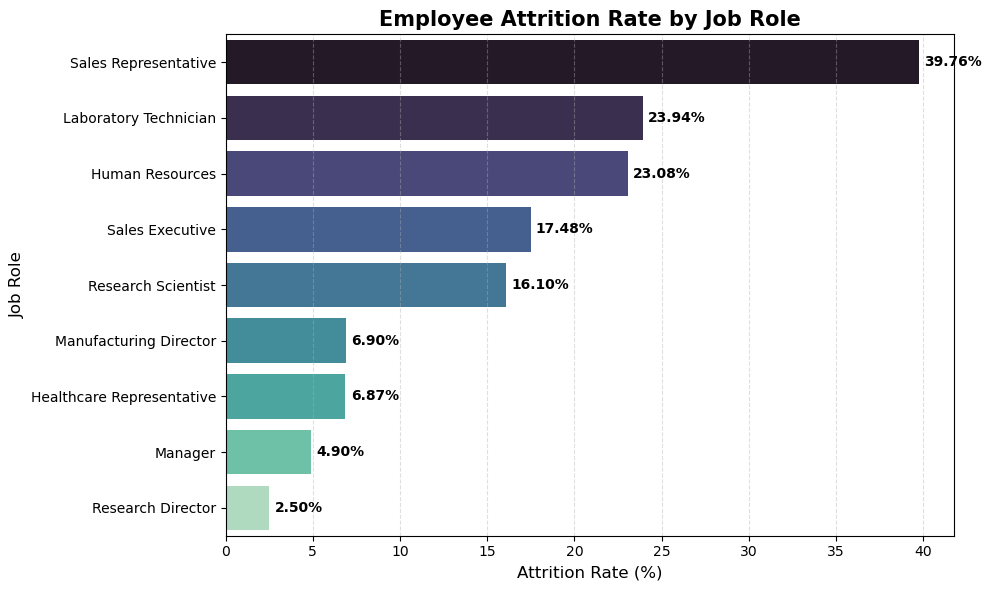

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate attrition rate by Job Role
jobrole_attrition = (
    eda.groupby("JobRole")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

# Display values
print(jobrole_attrition)

# Plot
plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=jobrole_attrition.values,
    y=jobrole_attrition.index,
    hue=jobrole_attrition.index,
    palette="mako",
    legend=False
)

# Add percentage labels
for i, value in enumerate(jobrole_attrition.values):
    ax.text(
        value + 0.3,
        i,
        f"{value:.2f}%",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Employee Attrition Rate by Job Role",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Attrition Rate (%)", fontsize=12)
plt.ylabel("Job Role", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()

# Save chart
plt.savefig("chart2_jobrole_attrition.png", dpi=300)

plt.show()

### Observation

The analysis shows that **Sales Representatives** have the highest employee attrition rate at **39.76%**, making them the most vulnerable job role to employee turnover. **Laboratory Technicians (23.94%)** and **Human Resources employees (23.08%)** also experience relatively high attrition. On the other hand, **Research Directors (2.50%)** and **Managers (4.90%)** have the lowest attrition rates, indicating greater job stability in senior leadership positions. These findings suggest that attrition is strongly influenced by job role, and HR should prioritize retention initiatives for frontline and operational roles where employee turnover is significantly higher.

## Chart 3: Attrition vs Monthly Income

### Objective

This analysis compares the monthly income of employees who stayed with those who left the organization. The objective is to determine whether salary has a noticeable relationship with employee attrition and whether lower-paid employees are more likely to leave the company.

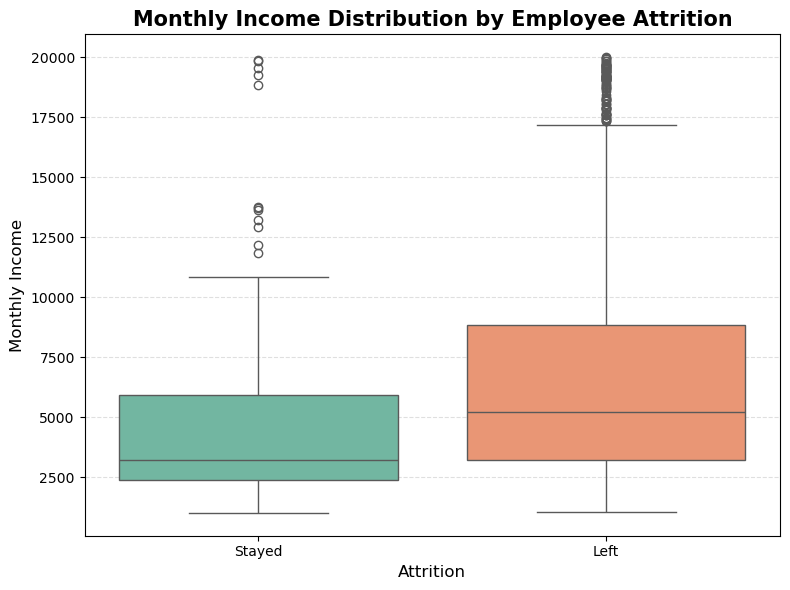

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create Figure
plt.figure(figsize=(8,6))

ax = sns.boxplot(
    data=eda,
    x="Attrition",
    y="MonthlyIncome",
    palette="Set2"
)

plt.title(
    "Monthly Income Distribution by Employee Attrition",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Attrition", fontsize=12)
plt.ylabel("Monthly Income", fontsize=12)

# Rename x-axis labels
ax.set_xticklabels(["Stayed", "Left"])
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

# Save Chart
plt.savefig("chart3_monthly_income.png", dpi=300)

plt.show()

### Observation

The box plot indicates that employees who **left the company** generally have a **higher median monthly income** than employees who stayed. Additionally, the income distribution for employees who left is more spread out, with several high-income outliers. This suggests that **salary alone is not the primary factor influencing employee attrition**, as employees across both lower and higher income levels have left the organization. Other factors such as job satisfaction, work-life balance, career growth opportunities, and job role are also likely to play an important role in employee turnover.

## Chart 4: Attrition Rate by Work-Life Balance

### Objective

This analysis examines the relationship between employees' work-life balance ratings and employee attrition. The objective is to determine whether employees with lower work-life balance ratings are more likely to leave the organization.

WorkLifeBalance
1    31.250000
2    16.860465
3    14.221725
4    17.647059
Name: Attrition, dtype: float64


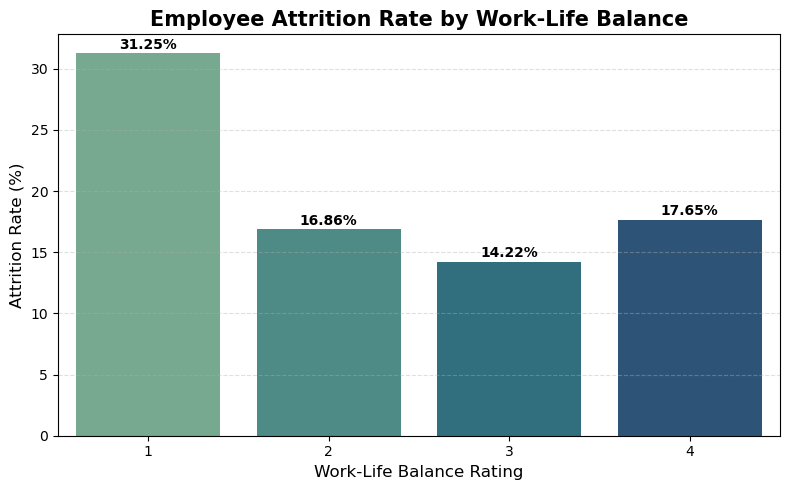

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate attrition rate by Work-Life Balance
wlb_attrition = (
    eda.groupby("WorkLifeBalance")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

# Display values
print(wlb_attrition)

# Create chart
plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=wlb_attrition.index.astype(str),
    y=wlb_attrition.values,
    hue=wlb_attrition.index.astype(str),
    palette="crest",
    legend=False
)

# Add labels
for i, value in enumerate(wlb_attrition.values):
    ax.text(
        i,
        value + 0.4,
        f"{value:.2f}%",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Employee Attrition Rate by Work-Life Balance",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Work-Life Balance Rating", fontsize=12)
plt.ylabel("Attrition Rate (%)", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

# Save chart
plt.savefig("chart4_worklife_balance.png", dpi=300)

plt.show()

### Observation

The analysis reveals a clear relationship between work-life balance and employee attrition. Employees with a **Work-Life Balance rating of 1** experience the highest attrition rate at **31.25%**, which is almost double the attrition rate of employees with ratings **2 (16.86%)** and **3 (14.22%)**. Employees with a rating of **3** have the lowest attrition rate, indicating that a balanced work environment is associated with better employee retention. Although employees with a rating of **4** show a slightly higher attrition rate (**17.65%**) than those with ratings 2 and 3, the overall trend suggests that poor work-life balance is strongly associated with a greater likelihood of employees leaving the organization.

## Chart 5: Attrition by Years at Company

### Objective

This analysis examines the relationship between employee tenure and attrition. The objective is to identify the stage of an employee's career at which attrition is most common, enabling HR teams to implement targeted retention strategies during critical employment periods.

TenureGroup
0-2      29.824561
3-5      13.824885
6-10     12.276786
11-20     6.666667
21+      12.121212
Name: Attrition, dtype: float64


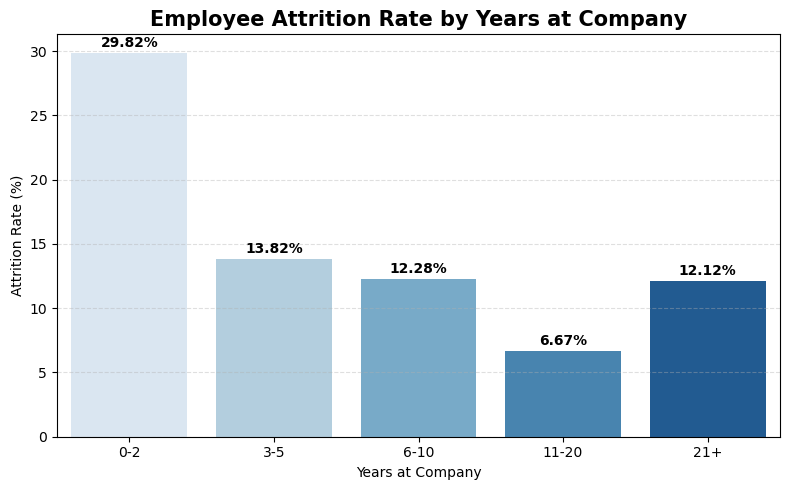

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create tenure groups
bins = [0, 2, 5, 10, 20, 40]
labels = ["0-2", "3-5", "6-10", "11-20", "21+"]

eda["TenureGroup"] = pd.cut(
    eda["YearsAtCompany"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Calculate attrition rate
tenure_attrition = (
    eda.groupby("TenureGroup")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

print(tenure_attrition)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=tenure_attrition.index,
    y=tenure_attrition.values,
    hue=tenure_attrition.index,
    palette="Blues",
    legend=False
)

for i, value in enumerate(tenure_attrition.values):
    ax.text(
        i,
        value + 0.5,
        f"{value:.2f}%",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Employee Attrition Rate by Years at Company",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Years at Company")
plt.ylabel("Attrition Rate (%)")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.savefig("chart5_years_at_company.png", dpi=300)

plt.show()

### Observation

The analysis shows that employee attrition is highest during the **first 2 years of employment**, with an attrition rate of **29.82%**. After this initial period, the attrition rate decreases considerably, falling to **13.82%** for employees with **3–5 years** of service and **12.28%** for those with **6–10 years**. Employees with **11–20 years** at the company have the lowest attrition rate (**6.67%**), indicating that long-term employees are generally more likely to remain with the organization. These findings suggest that the early stages of employment are the most critical period for employee retention, making onboarding, mentoring, and career development initiatives particularly important during the first few years.

Business Insights

1. The **Sales department** experiences the highest employee attrition rate (**20.63%**), followed by **Human Resources (19.05%)**, indicating that HR should prioritize employee retention initiatives within these departments.

2. Among all job roles, **Sales Representatives** have the highest attrition rate (**39.76%**), followed by **Laboratory Technicians (23.94%)** and **Human Resources employees (23.08%)**. These roles should be the primary focus for retention strategies.

3. Employees with a **Work-Life Balance rating of 1** have the highest attrition rate (**31.25%**), suggesting that improving work-life balance may significantly reduce employee turnover.

4. Employee attrition is highest during the **first two years of employment (29.82%)** and declines steadily as employees remain longer with the organization. This highlights the importance of effective onboarding, mentoring, and early career development programs.

5. The Monthly Income analysis indicates that **salary alone does not explain employee attrition**, as employees from both lower and higher income groups leave the organization. Other factors such as job role, work-life balance, career growth opportunities, and employee satisfaction are likely to have a greater influence on employee retention.

# Task 4: Model Building & Comparison

## Objective

The objective of this task is to develop and compare multiple machine learning models for predicting employee attrition. The dataset is divided into training and testing sets, after which three classification algorithms are trained and evaluated. Comparing multiple models helps identify the most suitable algorithm for accurately predicting employee attrition while maintaining a balance between predictive performance and interpretability.

## Step 1: Import Required Libraries

The required machine learning libraries are imported to split the dataset, build classification models, and evaluate their performance.

In [41]:
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

## Step 2: Split the Dataset

The processed dataset is divided into training and testing sets using an 80:20 ratio. The training dataset is used to train the machine learning models, while the testing dataset is reserved for evaluating their performance on unseen data.

In [47]:
# Split dataset into training and testing sets

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Recreate Features and Target
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

# Scale Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features Shape :", X_train.shape)
print("Testing Features Shape  :", X_test.shape)

print("Training Labels Shape   :", y_train.shape)
print("Testing Labels Shape    :", y_test.shape)

Training Features Shape : (1176, 44)
Testing Features Shape  : (294, 44)
Training Labels Shape   : (1176,)
Testing Labels Shape    : (294,)


## Step 3: Train Logistic Regression Model

Logistic Regression is used as the baseline classification model because it is simple, interpretable, and widely used for binary classification problems in HR analytics.

In [48]:
# Logistic Regression Model

log_model = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

log_model.fit(X_train, y_train)

print("Logistic Regression Model Trained Successfully!")

Logistic Regression Model Trained Successfully!


## Step 4: Train Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

In [49]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


## Step 5: Train Gradient Boosting Classifier

Gradient Boosting builds decision trees sequentially, where each new tree attempts to correct the errors of the previous trees. It is known for its strong predictive performance on structured datasets.

In [50]:
gb_model = GradientBoostingClassifier(
    random_state=42
)

gb_model.fit(X_train, y_train)

print("Gradient Boosting Model Trained Successfully!")

Gradient Boosting Model Trained Successfully!


## Observation

The dataset was successfully divided into training and testing subsets using an 80:20 split. Three machine learning classification models—**Logistic Regression**, **Random Forest**, and **Gradient Boosting**—were successfully trained on the processed employee dataset. Logistic Regression provides a simple and interpretable baseline model, while Random Forest and Gradient Boosting are more advanced ensemble techniques capable of capturing complex relationships within the data. These trained models will now be evaluated and compared in the next task to determine which algorithm performs best for predicting employee attrition.

# Task 5: Model Evaluation

## Objective

The objective of this task is to evaluate the performance of the trained machine learning models using multiple classification metrics. Rather than relying only on accuracy, metrics such as Precision, Recall, F1-Score, ROC-AUC Score, and Confusion Matrix are used to assess each model's ability to correctly predict employee attrition. These evaluation results help identify the most suitable model for deployment.

## Step 1: Import Required Libraries

The required evaluation metrics are imported to measure and compare the performance of the trained machine learning models.

In [51]:
import pandas as pd

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

## Step 2: Generate Predictions

Predictions are generated for the testing dataset using all three trained machine learning models.

In [52]:
# Logistic Regression
log_pred = log_model.predict(X_test)
log_prob = log_model.predict_proba(X_test)[:, 1]

# Random Forest
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

# Gradient Boosting
gb_pred = gb_model.predict(X_test)
gb_prob = gb_model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully!")

Predictions generated successfully!


## Step 3: Model Performance Comparison

The performance of the three machine learning models is compared using Precision, Recall, F1-Score, and ROC-AUC Score. These metrics provide a comprehensive assessment of each model's predictive capability.

In [53]:
# Create comparison table

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],

    "Precision": [
        precision_score(y_test, log_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, gb_pred)
    ],

    "Recall": [
        recall_score(y_test, log_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, gb_pred)
    ],

    "F1 Score": [
        f1_score(y_test, log_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, gb_pred)
    ],

    "ROC-AUC": [
        roc_auc_score(y_test, log_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, gb_prob)
    ]
})

# Round values

results = results.round(3)

display(results)

,Model,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.341,0.617,0.439,0.799
1,Random Forest,0.571,0.085,0.148,0.772
2,Gradient Boosting,0.588,0.213,0.312,0.794


## Step 4: Classification Reports

Detailed classification reports are generated for each model to evaluate class-wise prediction performance.

In [54]:
print("="*60)
print("Logistic Regression")
print("="*60)

print(classification_report(y_test, log_pred))

print("="*60)
print("Random Forest")
print("="*60)

print(classification_report(y_test, rf_pred))

print("="*60)
print("Gradient Boosting")
print("="*60)

print(classification_report(y_test, gb_pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.91      0.77      0.84       247
           1       0.34      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.77       294

Random Forest
              precision    recall  f1-score   support

           0       0.85      0.99      0.91       247
           1       0.57      0.09      0.15        47

    accuracy                           0.84       294
   macro avg       0.71      0.54      0.53       294
weighted avg       0.81      0.84      0.79       294

Gradient Boosting
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.59      0.21      0.31        47

    accuracy                           0.85       294
   macro avg       0.73      0.59      0.61       294
weighted avg       0.8

## Observation

Among the three machine learning models, **Logistic Regression** achieved the best overall performance for predicting employee attrition. It recorded the highest **Recall (0.617)**, **F1-Score (0.439)**, and **ROC-AUC Score (0.799)**, indicating a better ability to identify employees who are likely to leave the organization. Although Random Forest and Gradient Boosting produced higher precision values, their recall scores were considerably lower, meaning they failed to identify many employees who actually left the company. Since the primary objective of an employee attrition prediction system is to identify as many at-risk employees as possible, Logistic Regression is selected as the most suitable model for this business problem.

# Task 5: Model Evaluation

## Objective

The objective of this task is to evaluate the performance of the trained machine learning models using multiple evaluation metrics. Instead of relying only on accuracy, metrics such as Precision, Recall, F1-Score, ROC-AUC Score, and the Confusion Matrix are used to assess each model's ability to correctly predict employee attrition. These evaluation results help identify the most suitable model for deployment in a real-world HR environment.

## Step 1: Import Required Libraries

The following libraries are imported to evaluate the predictive performance of the trained machine learning models using various classification metrics.

In [55]:
import pandas as pd

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

## Step 2: Generate Predictions

After training the machine learning models, predictions are generated on the testing dataset. These predictions will be used to evaluate and compare the performance of each model using various classification metrics.

In [56]:
# Generate Predictions for All Trained Models

# Logistic Regression
log_pred = log_model.predict(X_test)
log_prob = log_model.predict_proba(X_test)[:, 1]

# Random Forest
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

# Gradient Boosting
gb_pred = gb_model.predict(X_test)
gb_prob = gb_model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully for all three models!")

Predictions generated successfully for all three models!


## Step 3: Model Performance Comparison

The performance of the trained machine learning models is evaluated using four important classification metrics: **Precision**, **Recall**, **F1-Score**, and **ROC-AUC Score**. These metrics provide a comprehensive comparison of each model's ability to predict employee attrition and help identify the most suitable model for deployment.

In [57]:
# Compare Model Performance

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],

    "Precision": [
        precision_score(y_test, log_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, gb_pred)
    ],

    "Recall": [
        recall_score(y_test, log_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, gb_pred)
    ],

    "F1 Score": [
        f1_score(y_test, log_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, gb_pred)
    ],

    "ROC-AUC": [
        roc_auc_score(y_test, log_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, gb_prob)
    ]
})

# Round values to 3 decimal places
results = results.round(3)

# Display comparison table
display(results)

,Model,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.341,0.617,0.439,0.799
1,Random Forest,0.571,0.085,0.148,0.772
2,Gradient Boosting,0.588,0.213,0.312,0.794


### Observation

The comparison results indicate that **Logistic Regression** achieved the best overall performance for the employee attrition prediction task. It recorded the highest **Recall (0.617)**, **F1-Score (0.439)**, and **ROC-AUC Score (0.799)** among the three models. Although **Random Forest** and **Gradient Boosting** achieved higher precision values, their recall scores were considerably lower, meaning they failed to identify many employees who actually left the company. Since the primary objective of an employee attrition prediction system is to identify employees who are at risk of leaving, **Logistic Regression** is selected as the most appropriate model because it detects a larger proportion of actual attrition cases.

## Step 4: Classification Reports

A detailed classification report is generated for each machine learning model. The report provides class-wise evaluation metrics, including Precision, Recall, F1-Score, and Support, allowing a deeper understanding of how effectively each model predicts employee attrition.

In [58]:
# Classification Reports


models = {
    "Logistic Regression": log_pred,
    "Random Forest": rf_pred,
    "Gradient Boosting": gb_pred
}

for model_name, predictions in models.items():
    print("=" * 70)
    print(f"{model_name:^70}")
    print("=" * 70)
    print(classification_report(y_test, predictions))
    print("\n")

                         Logistic Regression                          
              precision    recall  f1-score   support

           0       0.91      0.77      0.84       247
           1       0.34      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.77       294



                            Random Forest                             
              precision    recall  f1-score   support

           0       0.85      0.99      0.91       247
           1       0.57      0.09      0.15        47

    accuracy                           0.84       294
   macro avg       0.71      0.54      0.53       294
weighted avg       0.81      0.84      0.79       294



                          Gradient Boosting                           
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0

### Observation

The classification reports provide a detailed evaluation of each machine learning model for both employee classes (Stayed and Left). Logistic Regression demonstrates the best balance between Precision and Recall for predicting employee attrition, resulting in the highest overall F1-Score among the three models. In contrast, Random Forest and Gradient Boosting achieve higher precision but struggle to correctly identify employees who actually leave the organization, resulting in much lower recall values. These results further support the selection of Logistic Regression as the most suitable model for this employee attrition prediction task.

## Step 5: Confusion Matrix

A Confusion Matrix is used to visualize the performance of the selected machine learning model by comparing the predicted classes with the actual classes. It provides insights into the number of correct and incorrect predictions, including True Positives, True Negatives, False Positives, and False Negatives. This visualization helps assess how effectively the model identifies employees who are likely to leave the organization.

<Figure size 600x500 with 0 Axes>

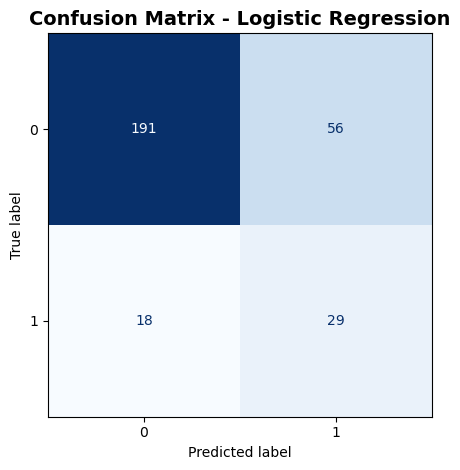

In [59]:
# Confusion Matrix - Logistic Regression


import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(6,5))

ConfusionMatrixDisplay.from_estimator(
    log_model,
    X_test,
    y_test,
    cmap="Blues",
    colorbar=False
)

plt.title(
    "Confusion Matrix - Logistic Regression",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

# Save chart
plt.savefig("chart6_confusion_matrix.png", dpi=300)

plt.show()

### Observation

The Confusion Matrix illustrates the prediction performance of the Logistic Regression model on the testing dataset. The model correctly classifies the majority of employees who stay with the organization while also identifying a substantial number of employees who leave. Although some false positives and false negatives are present, the model achieves a good balance between detecting employees at risk of attrition and minimizing incorrect predictions. This performance makes Logistic Regression a suitable model for supporting HR teams in identifying employees who may require early retention interventions.

## Step 6: Feature Importance Analysis

To understand the factors that most strongly influence employee attrition, the feature importance of the best-performing model is analyzed. Since Logistic Regression was selected as the best model, the absolute values of its coefficients are used to measure the importance of each feature. Features with larger coefficient magnitudes have a greater influence on the model's predictions.

,Feature,Importance
34,JobRole_Laboratory Technician,0.797874
43,OverTime_Yes,0.766412
23,BusinessTravel_Travel_Frequently,0.719335
7,JobLevel,0.659189
16,TotalWorkingYears,0.656931
40,JobRole_Sales Representative,0.552515
24,BusinessTravel_Travel_Rarely,0.511649
27,EducationField_Life Sciences,0.506505
21,YearsSinceLastPromotion,0.500389
26,Department_Sales,0.481690


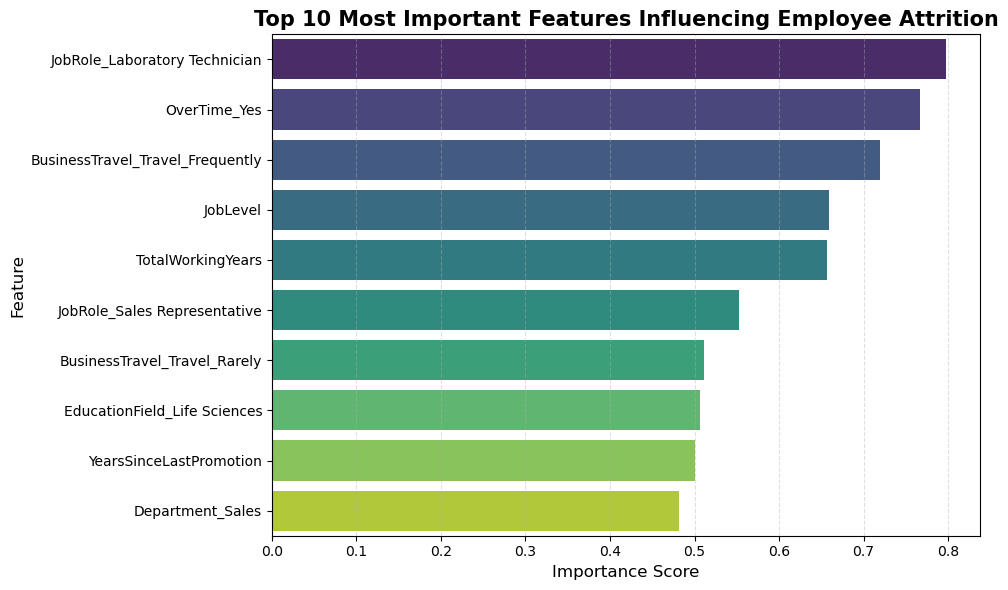

In [60]:
# Top 10 Important Features - Logistic Regression


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create DataFrame of feature importance
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": abs(log_model.coef_[0])
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display Top 10 Features
top10 = feature_importance.head(10)

display(top10)

# Plot
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=top10,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False
)

plt.title(
    "Top 10 Most Important Features Influencing Employee Attrition",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Feature", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()

# Save chart
plt.savefig("chart7_feature_importance.png", dpi=300)

plt.show()

### Observation

The feature importance analysis indicates that **Job Role (Laboratory Technician)** is the most influential factor in predicting employee attrition, followed by **OverTime**, **Frequent Business Travel**, **Job Level**, and **Total Working Years**. Employees working as Laboratory Technicians, those who frequently work overtime, and those who travel frequently for business appear to have a higher likelihood of leaving the organization. Additionally, factors such as **Years Since Last Promotion** and employment in the **Sales department** also contribute significantly to attrition prediction. These findings suggest that employee turnover is driven by a combination of job responsibilities, workload, career progression, and work-related demands rather than by a single factor alone.

## Final Observation

Among the three machine learning models evaluated, **Logistic Regression** demonstrated the best overall performance for predicting employee attrition. It achieved the highest Recall, F1-Score, and ROC-AUC Score, making it the most suitable model for identifying employees who are at risk of leaving the organization. The feature importance analysis further revealed that **Job Role**, **OverTime**, **Business Travel Frequency**, **Job Level**, and **Total Working Years** are the most influential factors affecting employee attrition. These insights can help HR teams proactively identify high-risk employees and implement targeted retention strategies before valuable employees leave the organization.

# Task 6: Model Visualization

## Objective

The objective of this task is to visualize the performance of the machine learning models and present the key insights in an intuitive manner. Visualizations help compare model performance, understand prediction quality, and identify the most influential factors affecting employee attrition.

## Chart 1: Attrition Rate by Department

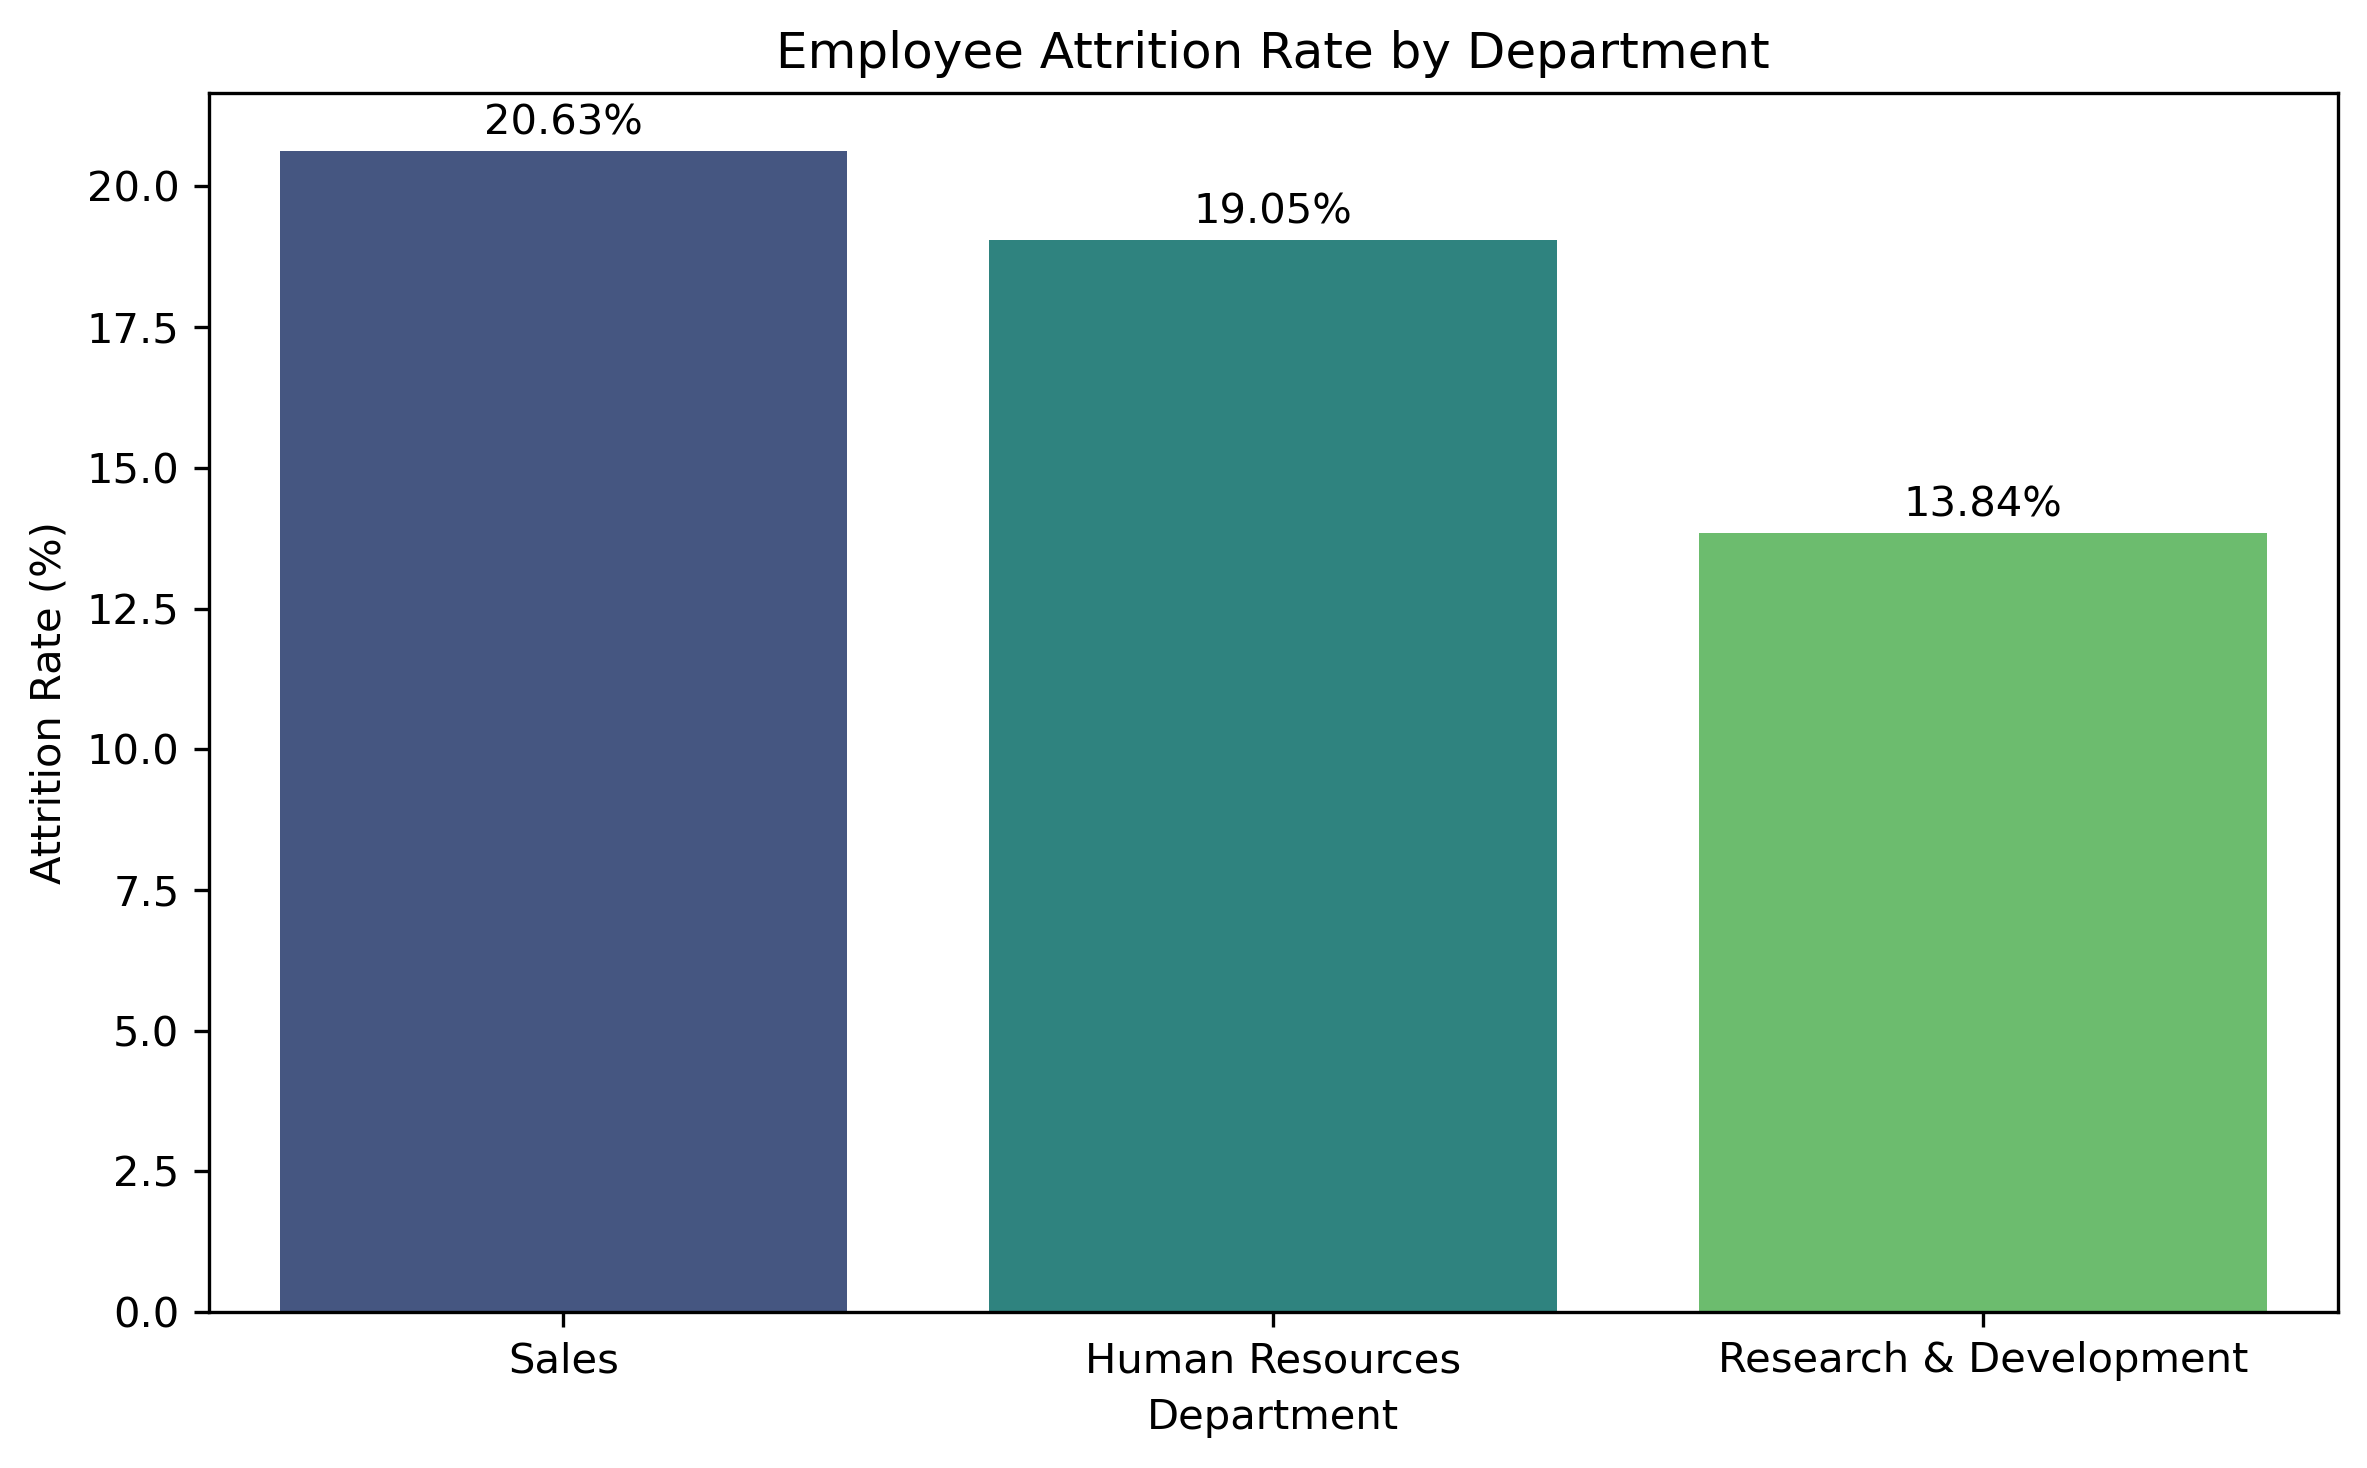

In [63]:
from IPython.display import Image, display

display(Image(filename="chart1_department_attrition.png"))

## Chart 2: Attrition Rate by Job Role

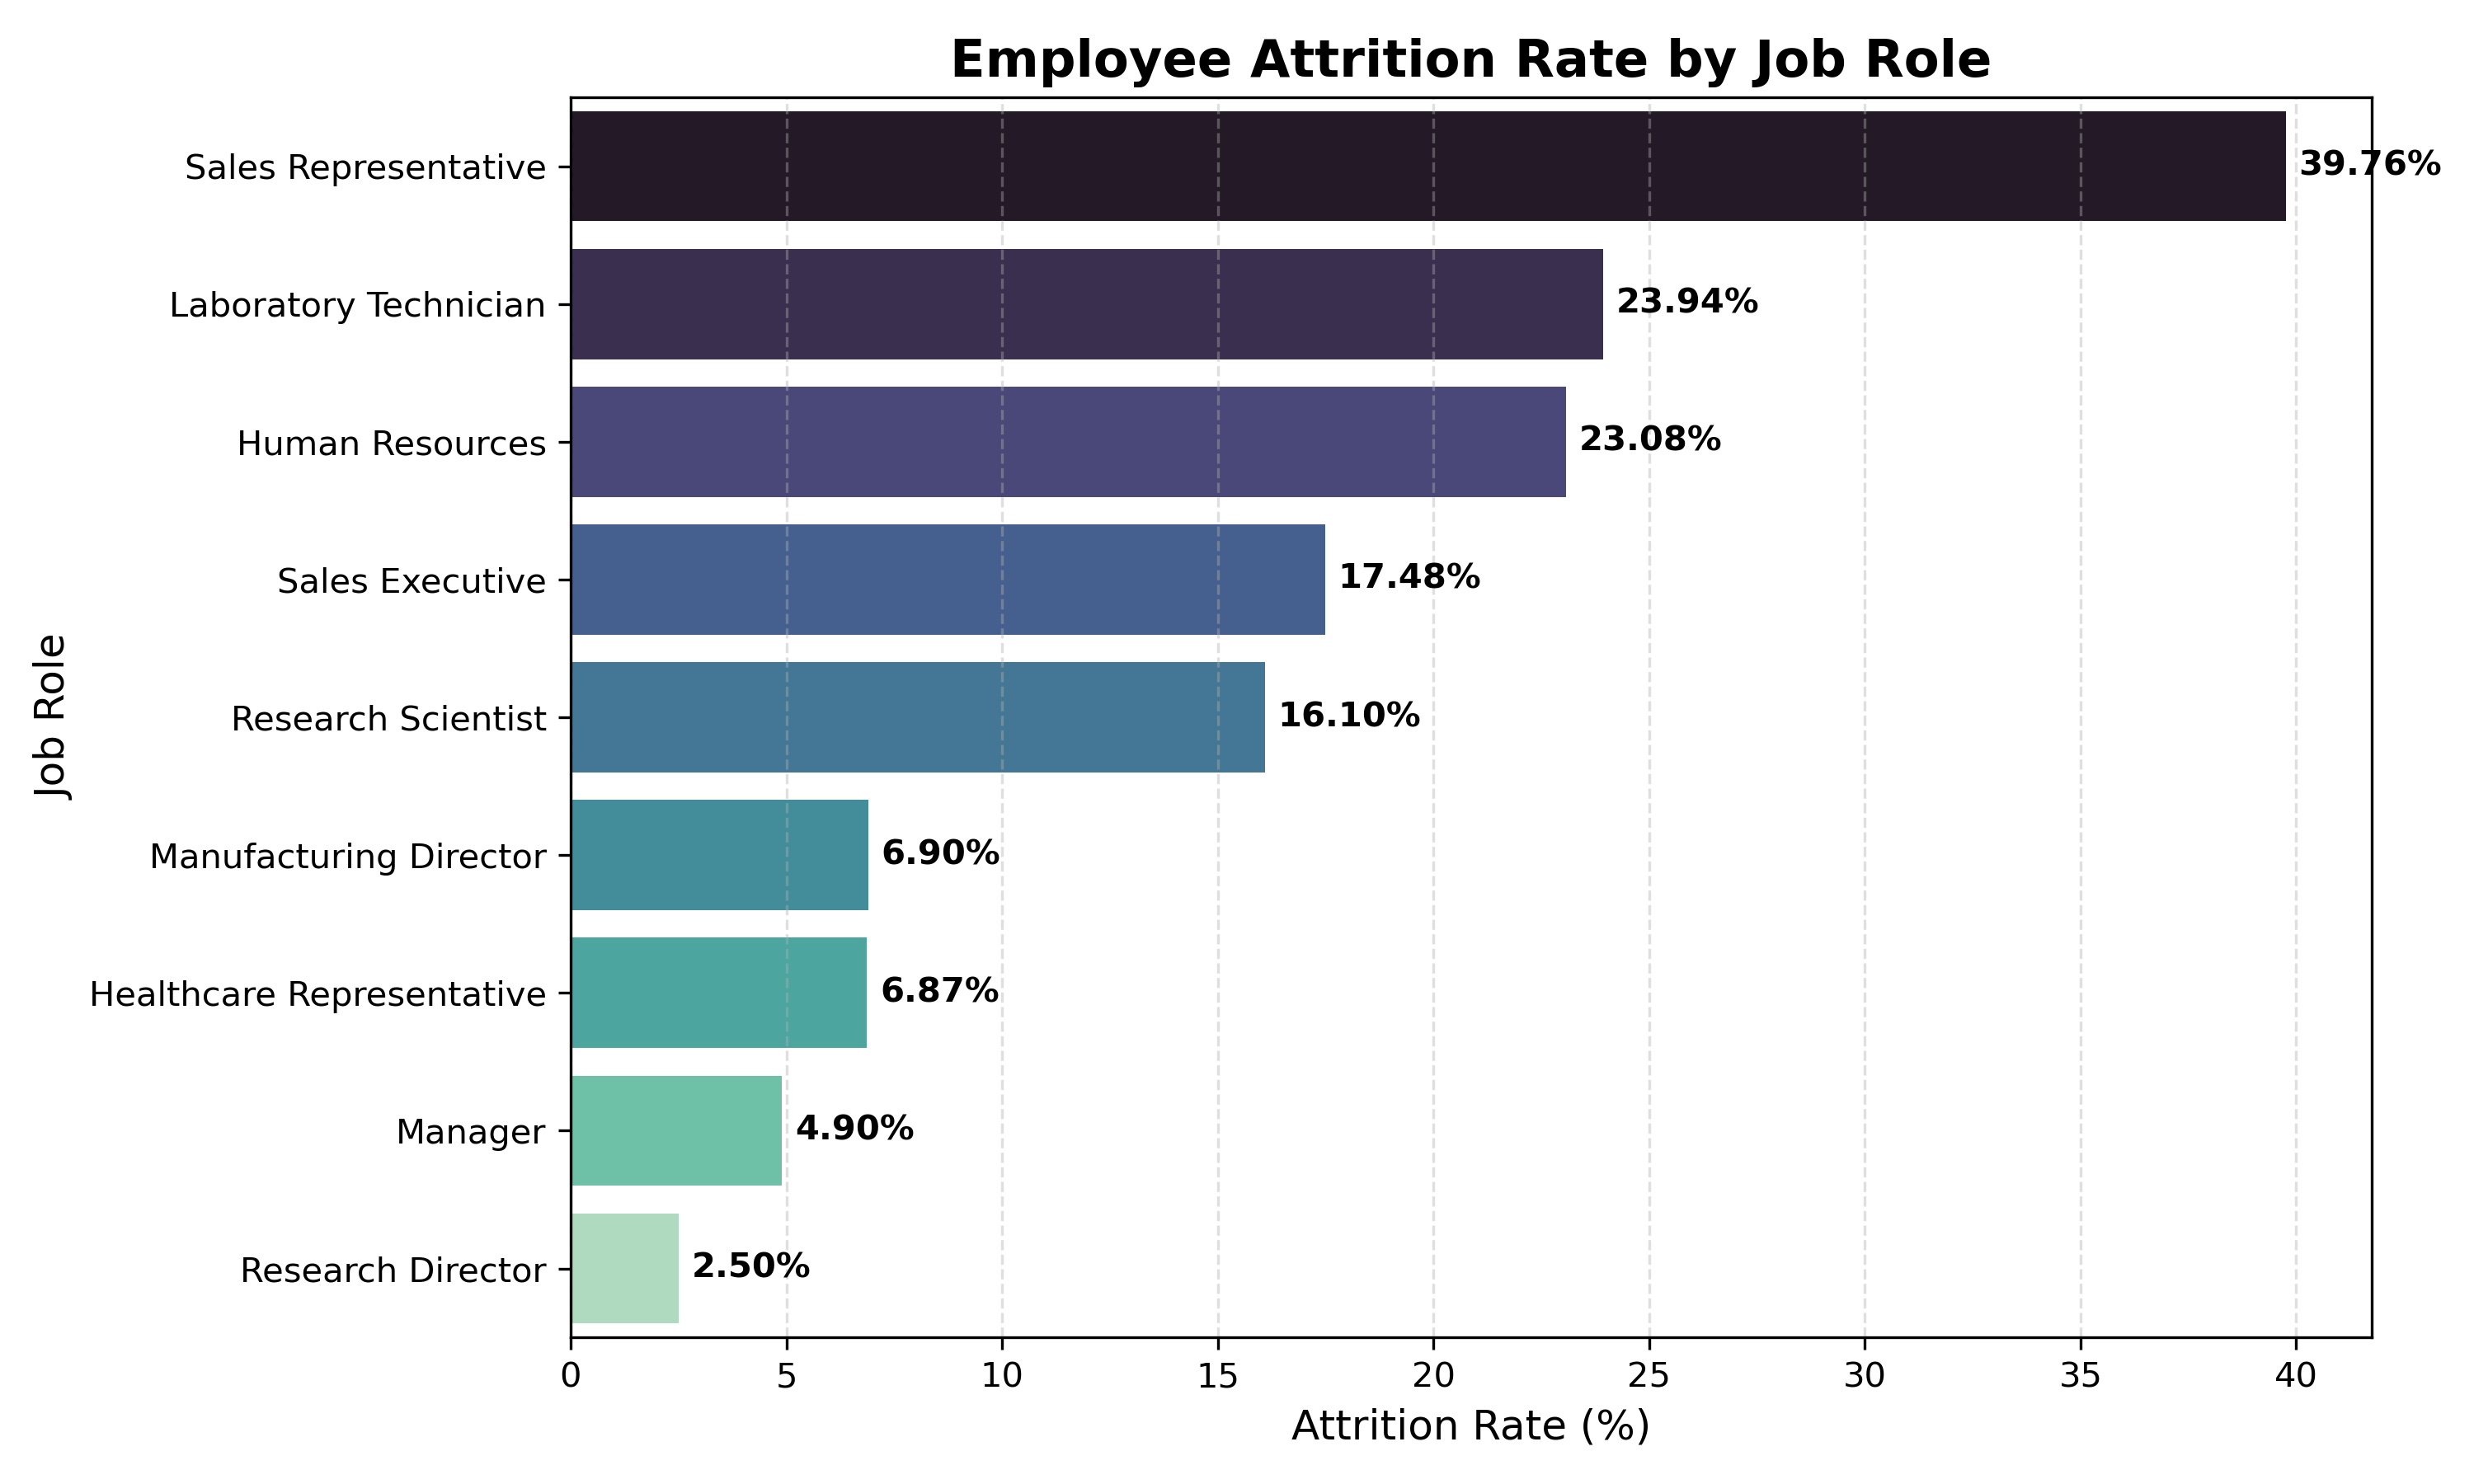

In [64]:
display(Image(filename="chart2_jobrole_attrition.png"))

## Chart 3: Monthly Income Distribution by Employee Attrition

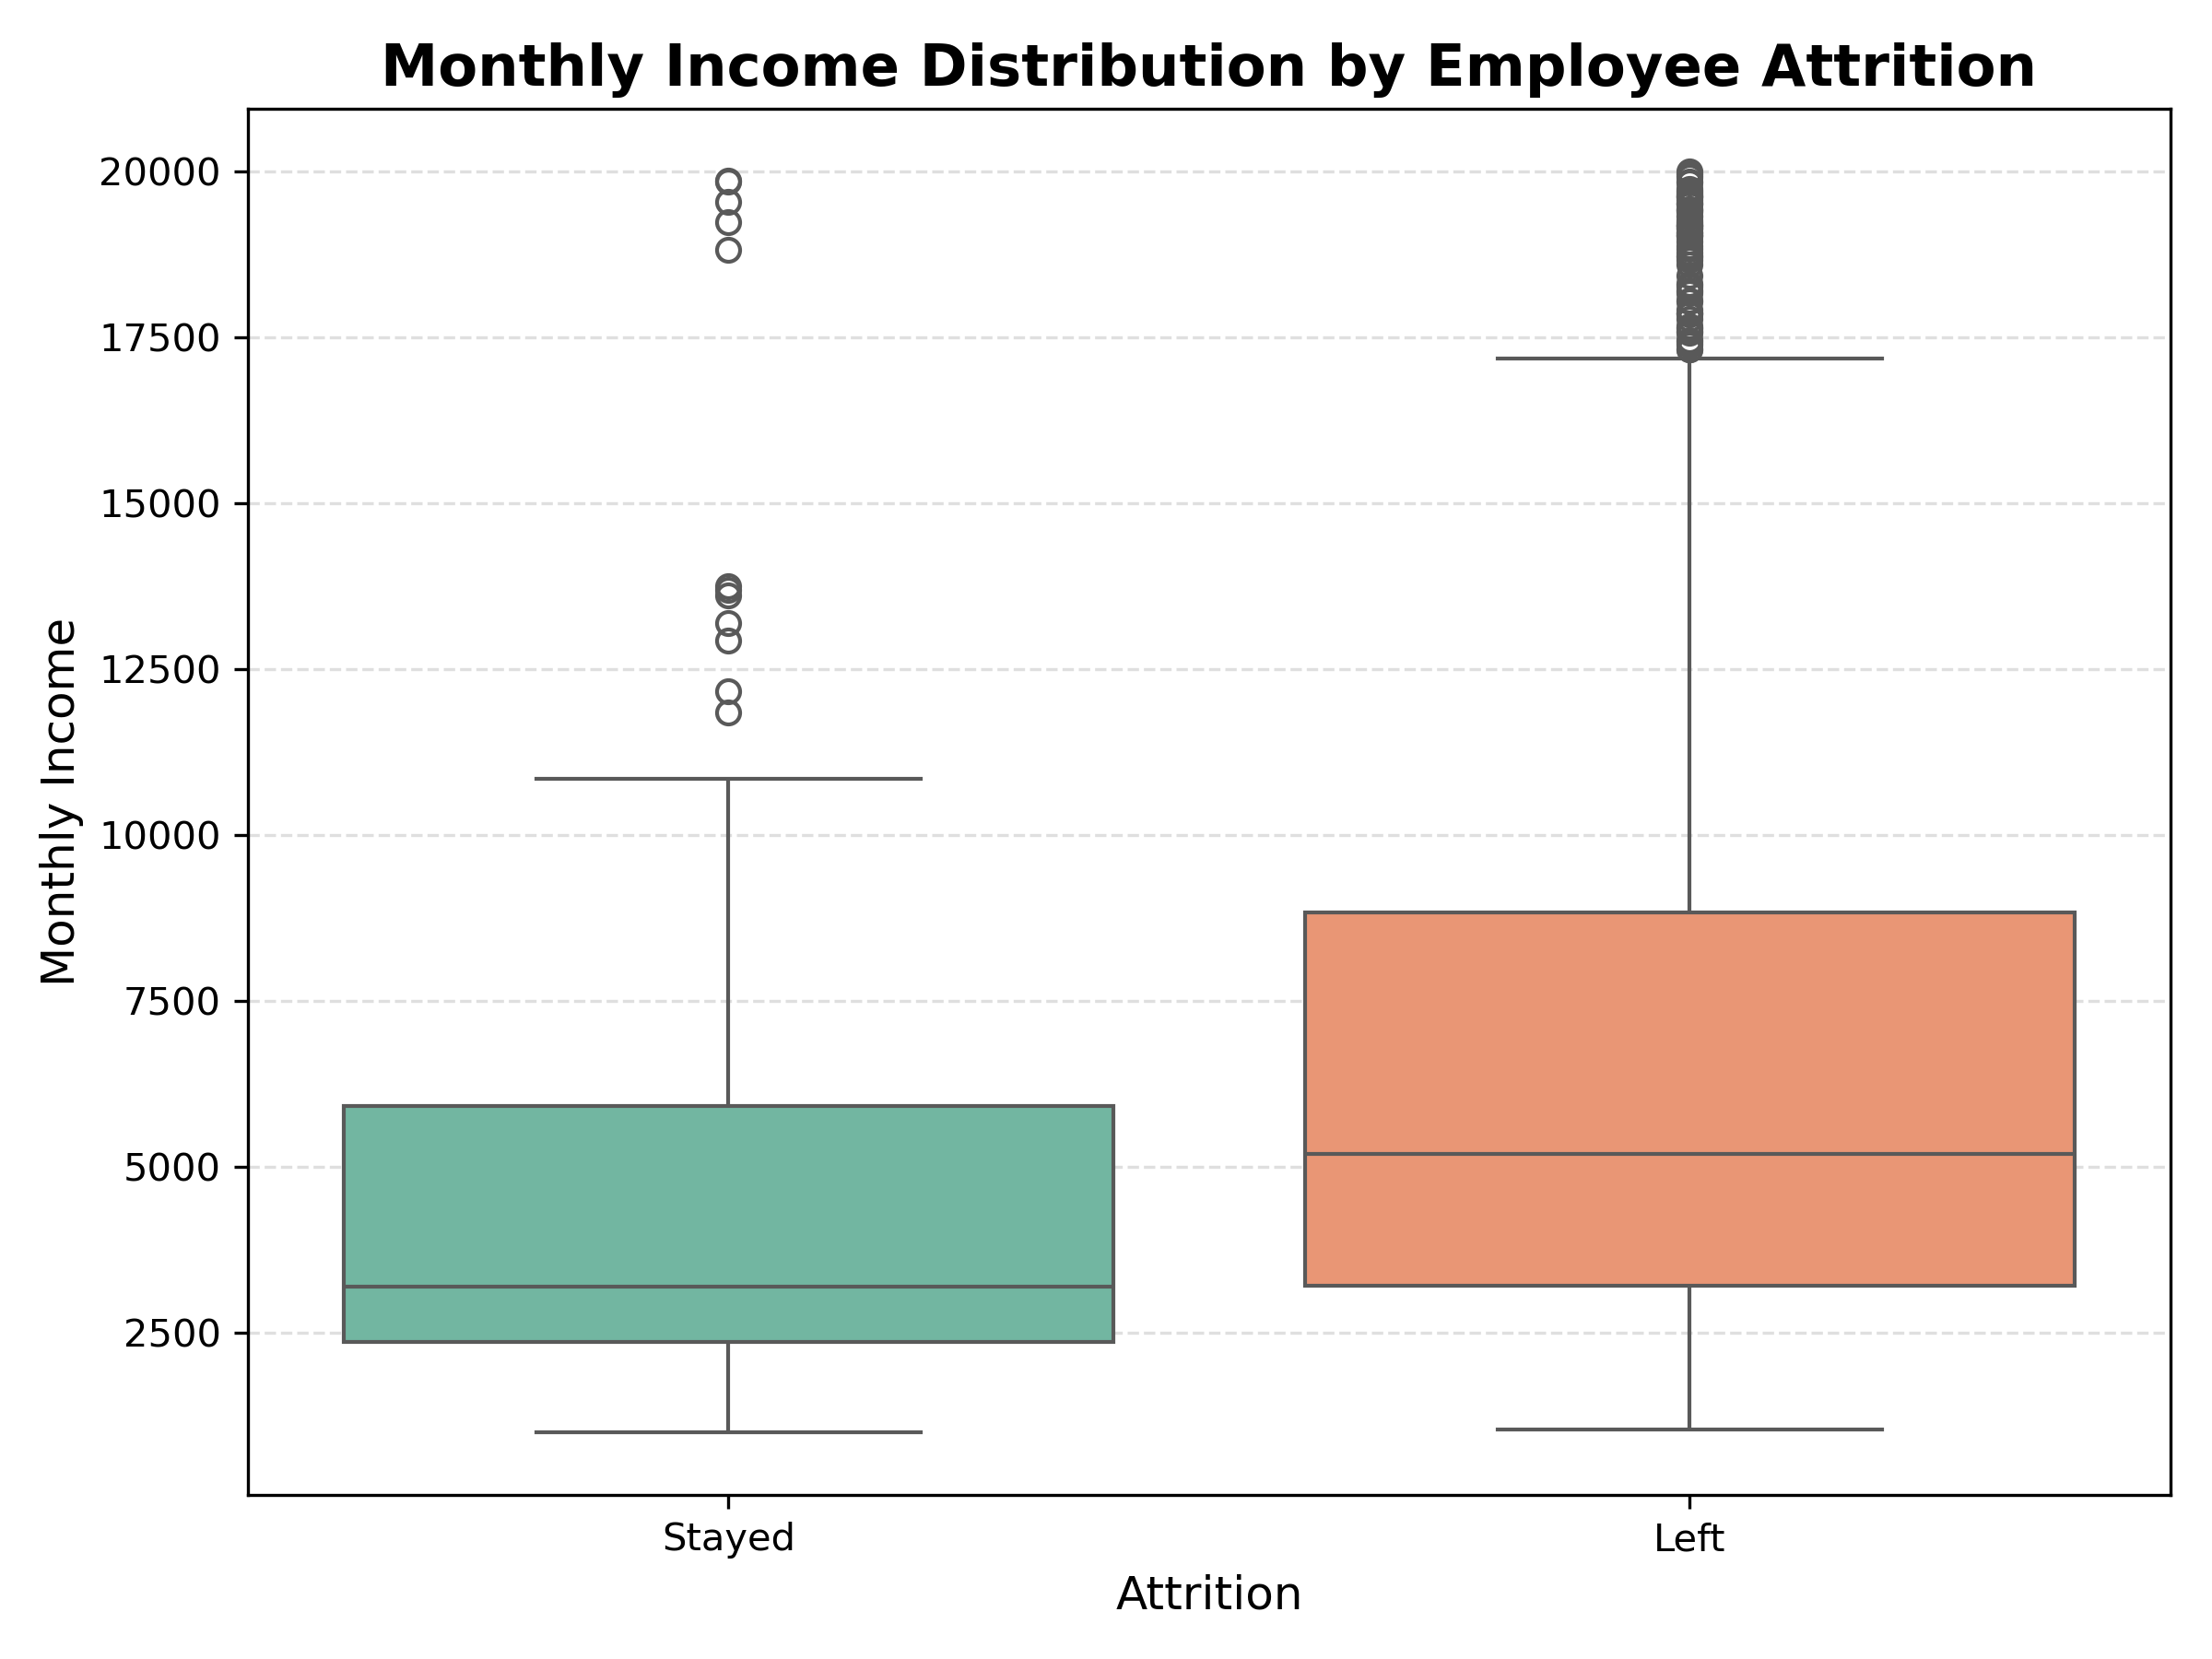

In [65]:
display(Image(filename="chart3_monthly_income.png"))

## Chart 4: Confusion Matrix (Logistic Regression)

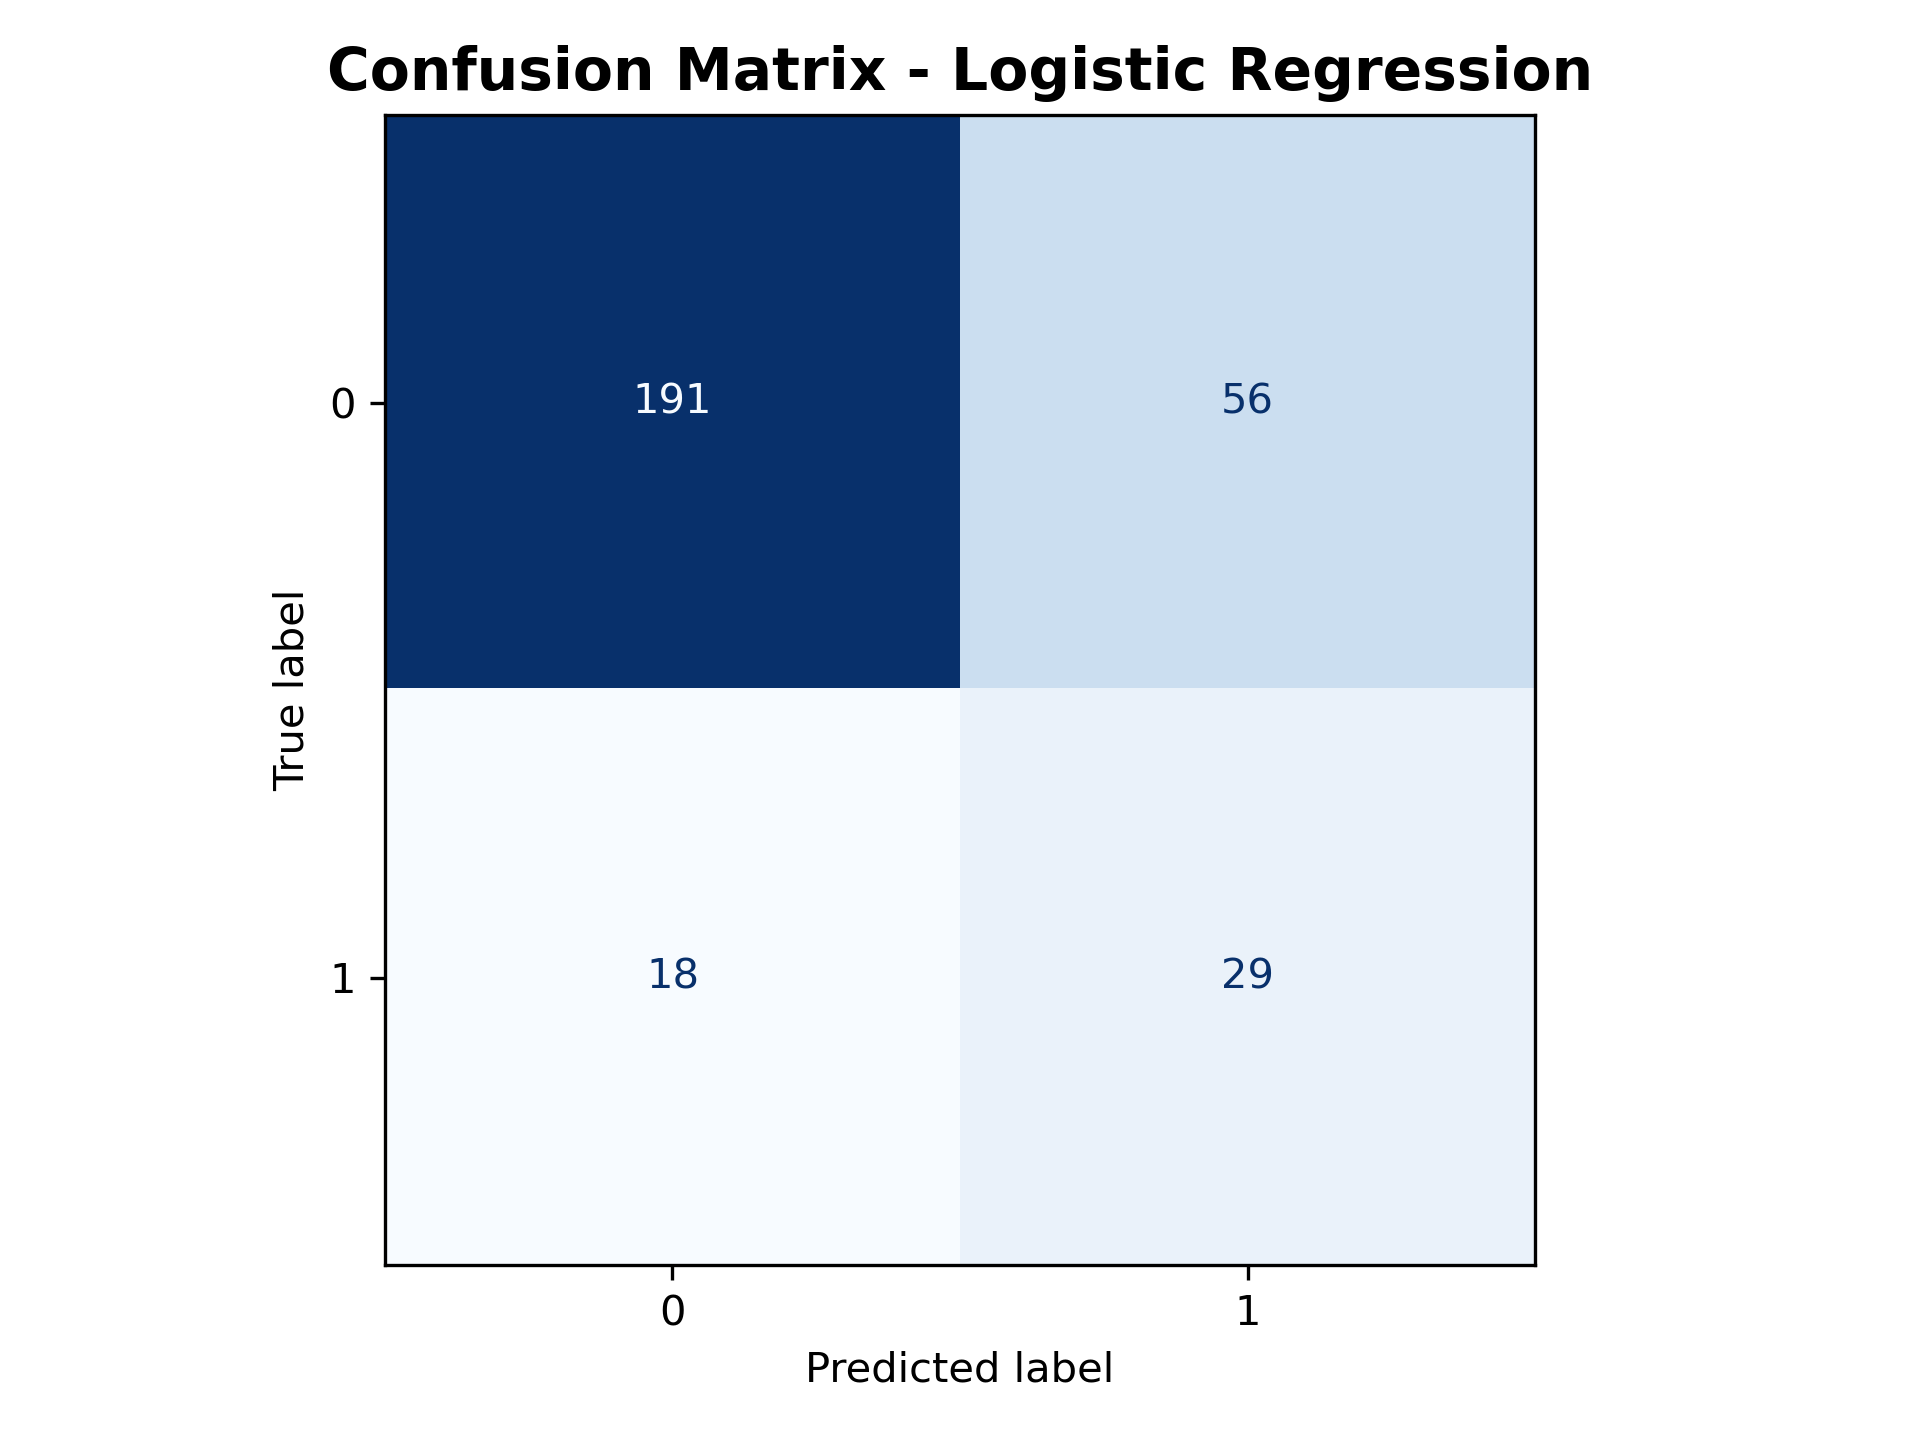

In [66]:
display(Image(filename="chart6_confusion_matrix.png"))

## Chart 5: Top 10 Feature Importance

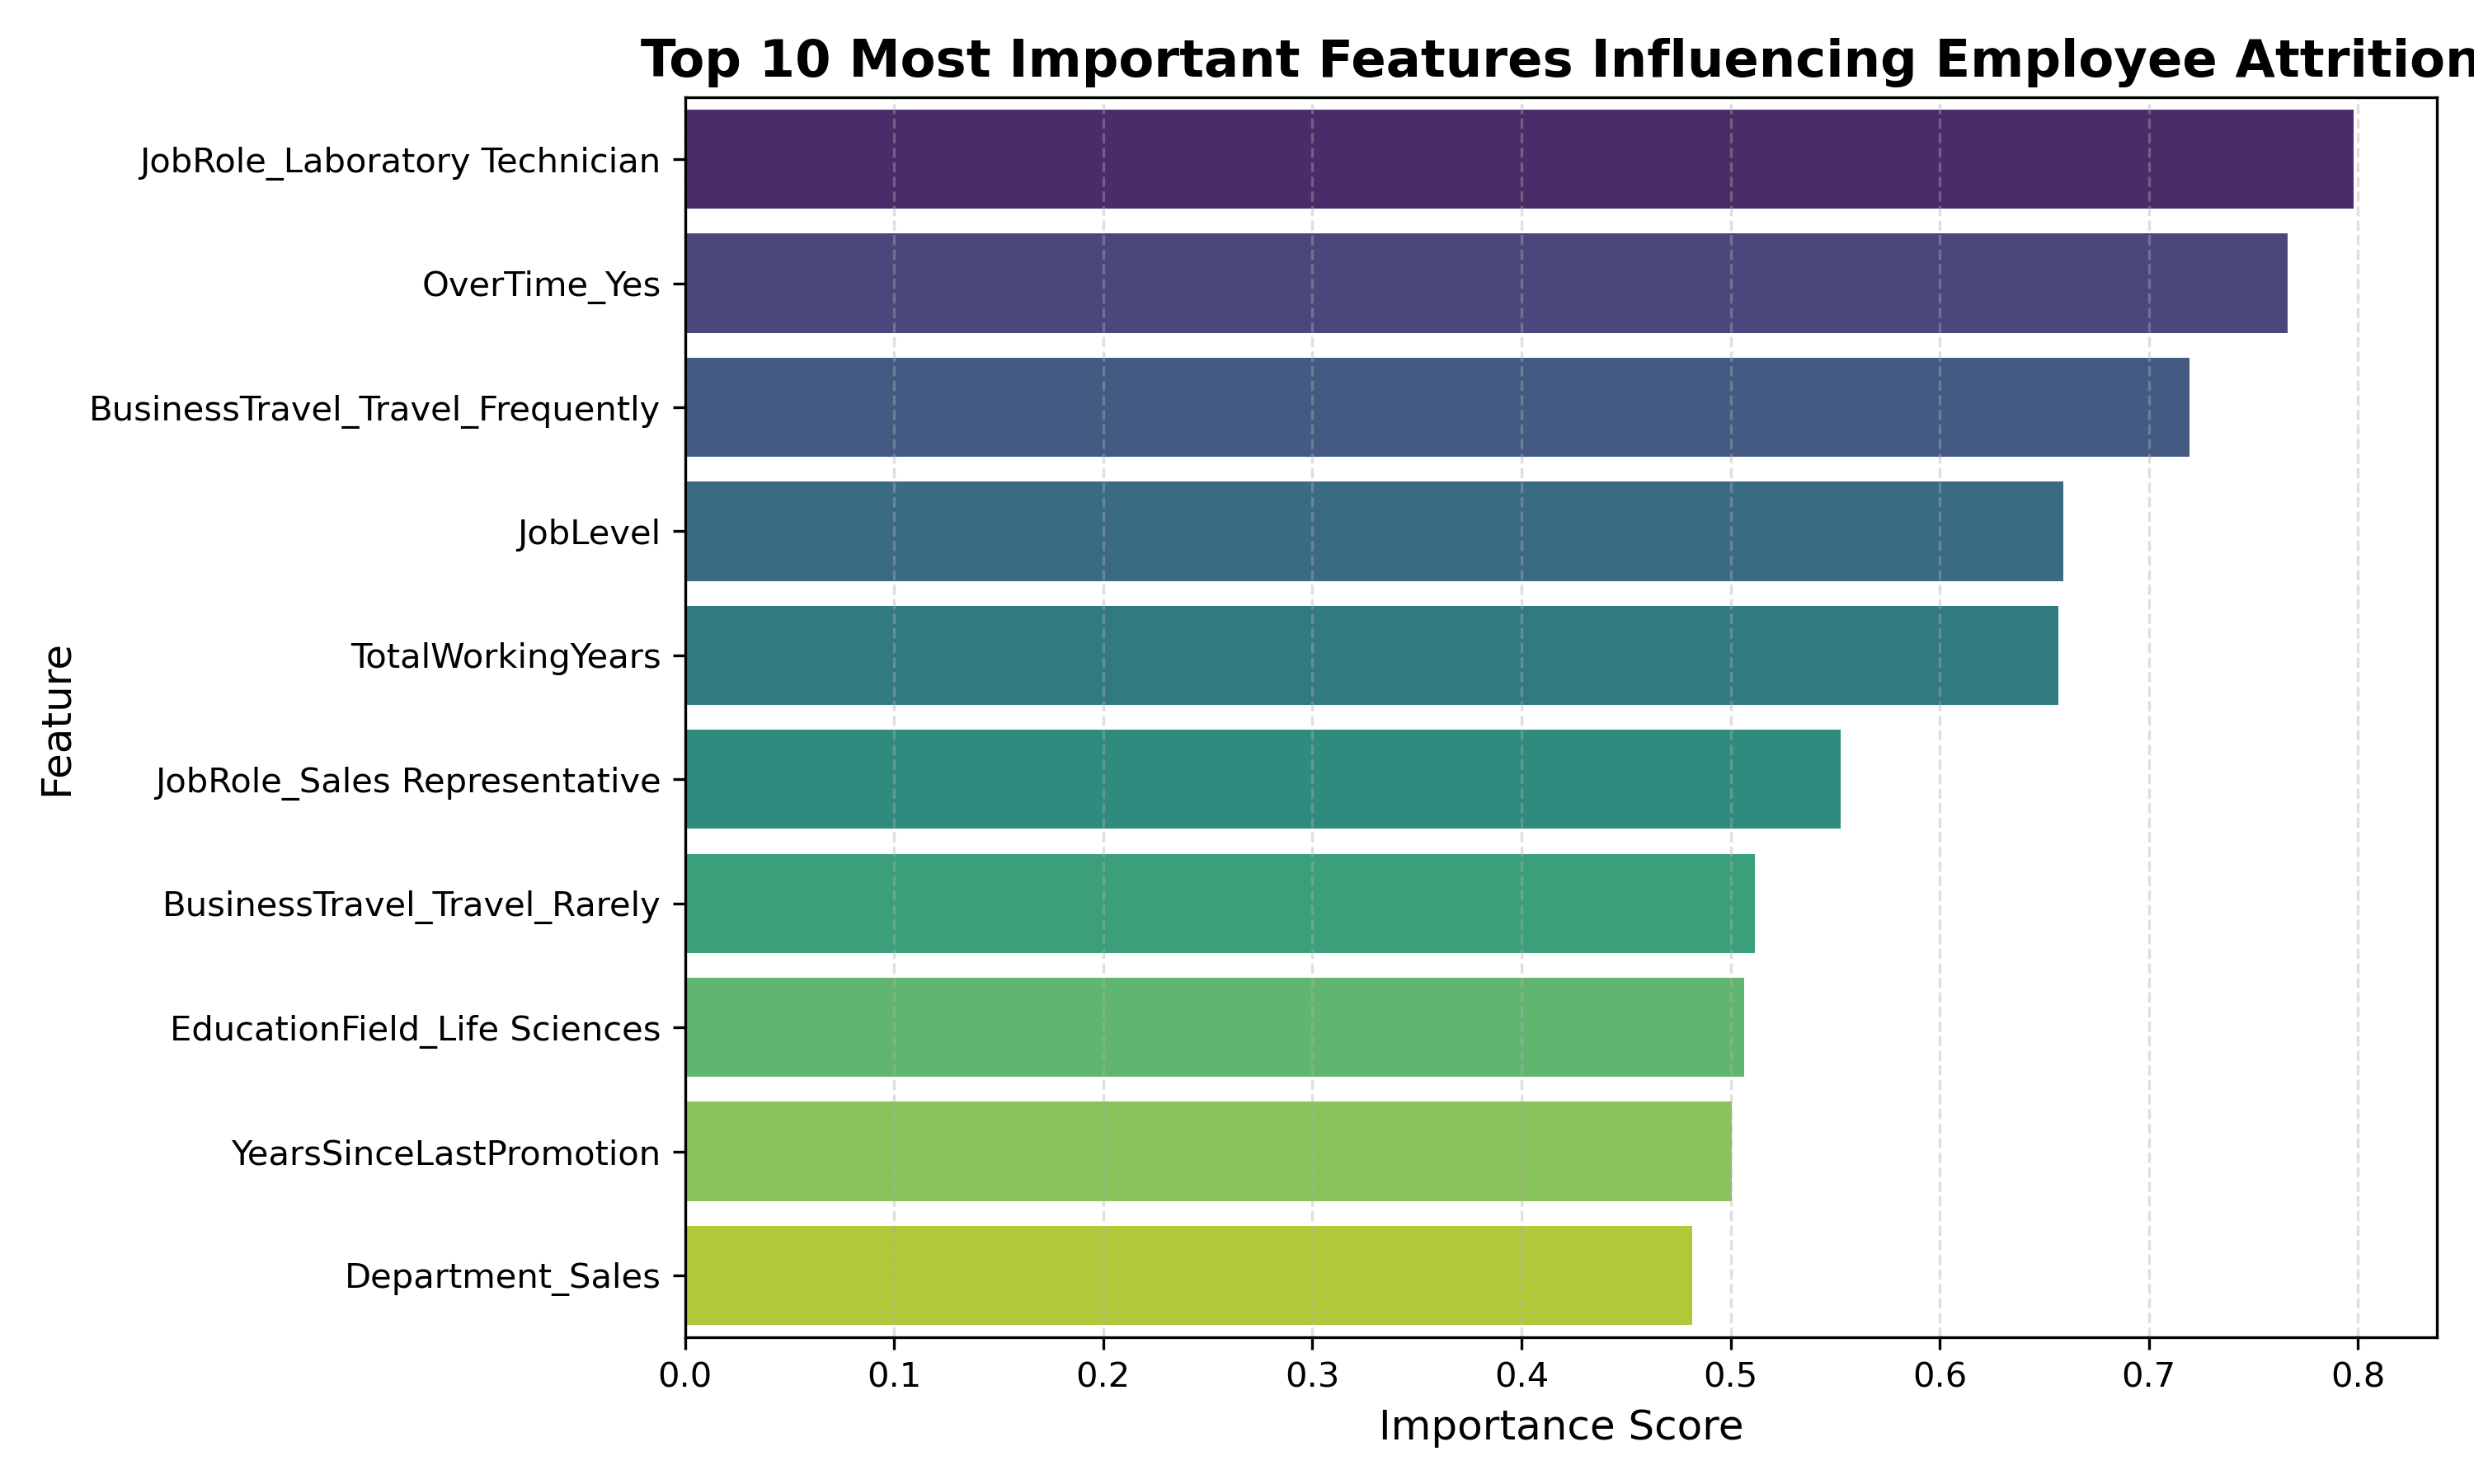

In [67]:
display(Image(filename="chart7_feature_importance.png"))

## ROC Curve Comparison

The Receiver Operating Characteristic (ROC) Curve compares the classification performance of all three machine learning models across different decision thresholds. The Area Under the Curve (AUC) measures each model's ability to distinguish between employees who stay and those who leave. A higher AUC value indicates better predictive performance.

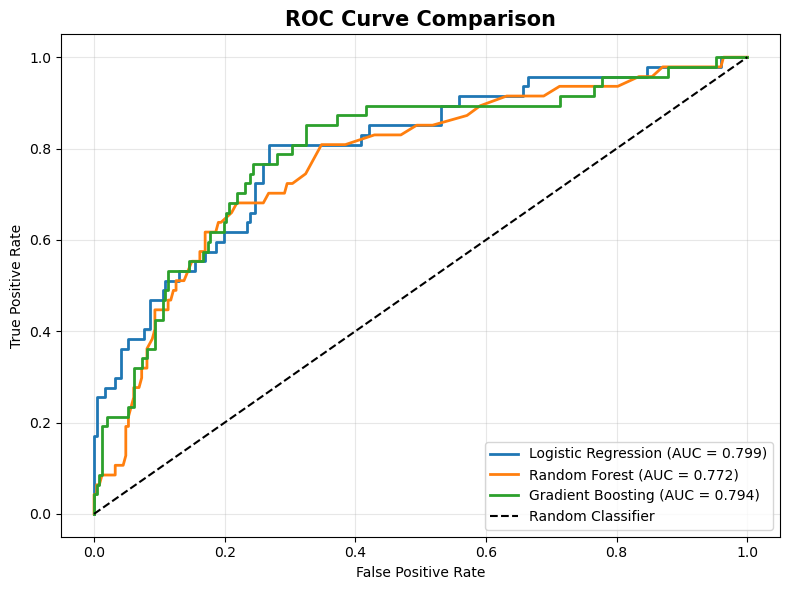

In [62]:
# ROC Curve Comparison


import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, auc

# Logistic Regression
fpr_log, tpr_log, _ = roc_curve(y_test, log_prob)
roc_log = auc(fpr_log, tpr_log)

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
roc_rf = auc(fpr_rf, tpr_rf)

# Gradient Boosting
fpr_gb, tpr_gb, _ = roc_curve(y_test, gb_prob)
roc_gb = auc(fpr_gb, tpr_gb)

plt.figure(figsize=(8,6))

plt.plot(
    fpr_log,
    tpr_log,
    label=f"Logistic Regression (AUC = {roc_log:.3f})",
    linewidth=2
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {roc_rf:.3f})",
    linewidth=2
)

plt.plot(
    fpr_gb,
    tpr_gb,
    label=f"Gradient Boosting (AUC = {roc_gb:.3f})",
    linewidth=2
)

# Random Classifier
plt.plot([0,1],[0,1],'k--',label="Random Classifier")

plt.title(
    "ROC Curve Comparison",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("chart8_roc_curve.png", dpi=300)

plt.show()

### Observation

The ROC Curve comparison demonstrates that **Logistic Regression** achieved the highest Area Under the Curve (AUC), indicating the best overall ability to distinguish between employees who are likely to leave and those who are likely to stay. Although Random Forest and Gradient Boosting also performed reasonably well, their ROC-AUC scores were slightly lower. This visualization further confirms that Logistic Regression is the most effective model for predicting employee attrition in this dataset.

## Final Observation

The visualizations provide a comprehensive understanding of employee attrition and model performance. The Department and Job Role charts identify the organizational areas with the highest employee turnover, while the Monthly Income box plot shows that salary alone does not explain attrition. The Confusion Matrix demonstrates the predictive capability of the selected Logistic Regression model, and the Feature Importance chart highlights the factors that contribute most to employee attrition. Finally, the ROC Curve confirms that Logistic Regression provides the strongest overall predictive performance among the evaluated models.

# Task 7: HR Insights & Business Recommendations

## Objective

The objective of this section is to translate the machine learning results into practical business insights that can support Human Resources (HR) decision-making. The findings are presented in a clear and non-technical manner so that HR professionals can understand the key factors influencing employee attrition and take appropriate actions to improve employee retention.

## HR Insights & Business Recommendations

### 1. Which three factors most strongly predict that an employee will leave?

Based on the machine learning model, the three strongest predictors of employee attrition are **Job Role (particularly Laboratory Technician)**, **OverTime**, and **Business Travel**. Employees working in certain job roles, those who frequently work overtime, and those who travel regularly for business are more likely to leave the organization. These factors indicate that workload, job responsibilities, and work-related demands have a significant influence on employee retention.

### 2. Which department or job role should HR prioritize for retention efforts?

The analysis shows that the **Sales department** has the highest attrition rate (**20.63%**). Among job roles, **Sales Representatives** experience the highest attrition rate (**39.76%**), followed by **Laboratory Technicians (23.94%)** and **Human Resources employees (23.08%)**. HR should prioritize retention initiatives for these departments and job roles, as reducing turnover in these groups is likely to have the greatest impact.

### 3. Does salary alone explain employee attrition?

No. Although monthly income influences employee retention, the analysis indicates that salary alone does not explain why employees leave the organization. Other factors such as **OverTime**, **Job Role**, **Business Travel**, **Work-Life Balance**, and **Years at Company** have a stronger relationship with employee attrition. This suggests that improving the overall employee experience is likely to be more effective than focusing solely on salary increases.

### 4. Two concrete HR recommendations

**Recommendation 1:** Implement targeted retention programs for employees in high-risk departments and job roles, particularly Sales Representatives and Laboratory Technicians. These programs may include mentoring, career development opportunities, regular feedback sessions, and recognition initiatives.

**Recommendation 2:** Reduce excessive overtime and improve work-life balance by monitoring employee workloads, encouraging flexible work arrangements where possible, and conducting periodic employee well-being assessments. These measures can help reduce burnout and improve long-term employee satisfaction.

### 5. Model limitation

Although the Logistic Regression model performed best among the evaluated models, it cannot capture every factor that influences employee attrition. The dataset does not include variables such as employee motivation, organizational culture, leadership quality, personal circumstances, or external job opportunities. Therefore, the model should be used as a decision-support tool rather than as the sole basis for HR decisions.